# Clade A results

In [499]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_A.py grid_params.py


In [500]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *

import elfi_vis
importlib.reload(elfi_vis)
from elfi_vis import *

Loading BSI_functions.py
Grid parameters:
Clade: A
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     3.895481
2005     0.000395
2006    12.635743
2007     4.214390
2008    10.536233
2009     5.791327
2010    15.351836
2011     8.640565
2012    23.632022
2013    31.851170
2014    30.044468
2015    10.125092
2016    20.251191
2017    21.300956
Name: A, dtype: float64
Model imported


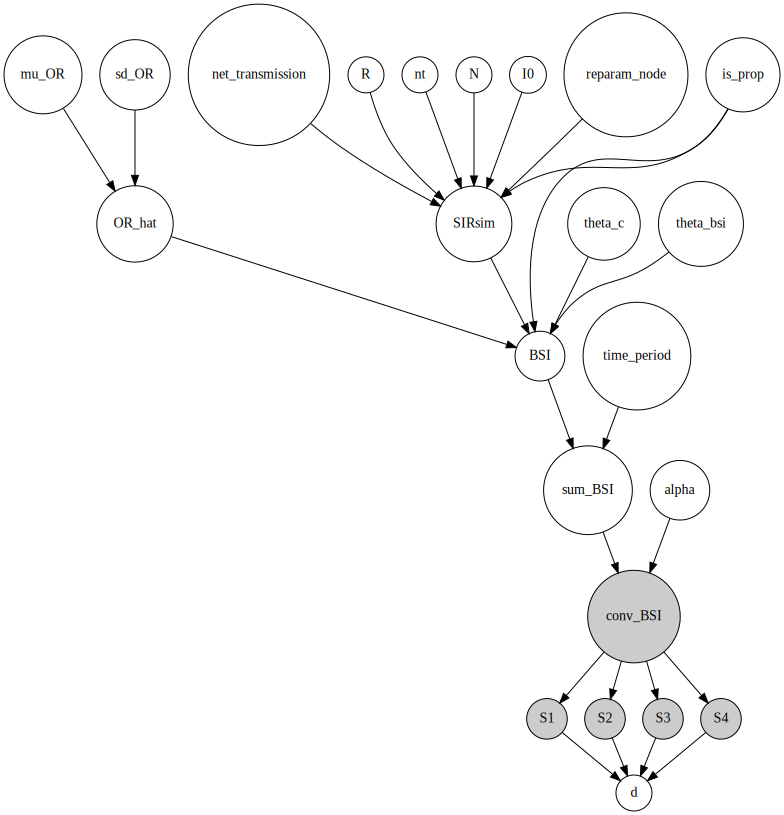

In [501]:
elfi.draw(m)

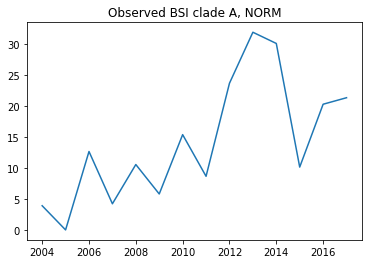

In [502]:
# Plot the observed data

plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.show()


## Visualizing the Prior

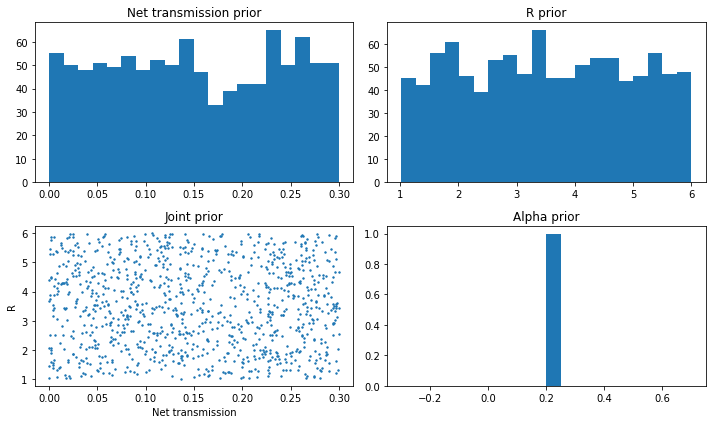

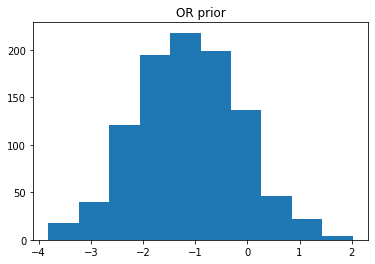

In [503]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{par2} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{par2}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.show()

if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.show()
    

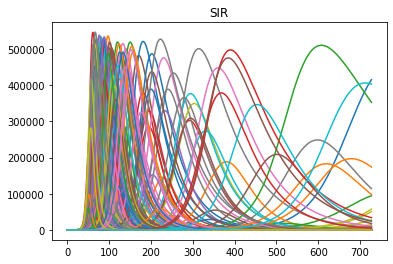

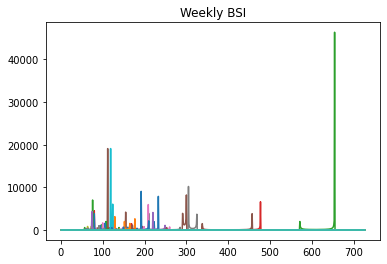

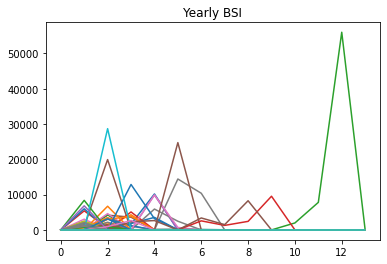

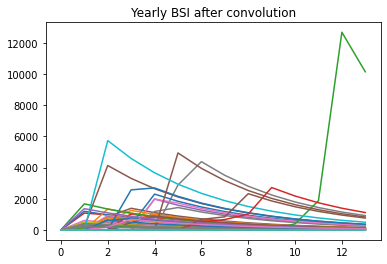

In [504]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 200, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])


plt.plot(sim_dict["SIRsim"][1][0:200].T)
plt.title("SIR")
plt.show()

plt.plot(sim_dict["BSI"][0:200].T)
plt.title("Weekly BSI")
plt.show()

plt.plot(sim_dict["sum_BSI"][0:200].T)
plt.title("Yearly BSI")
plt.show()

plt.plot(sim_dict["conv_BSI"][0:200].T)
plt.title("Yearly BSI after convolution")
plt.show()


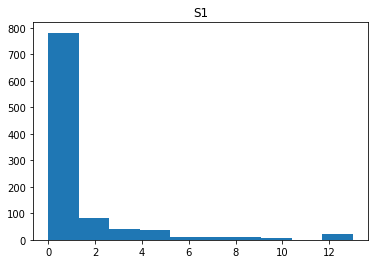

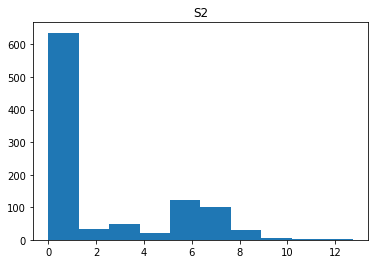

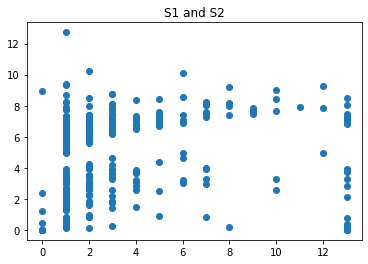

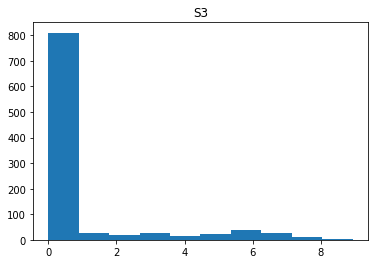

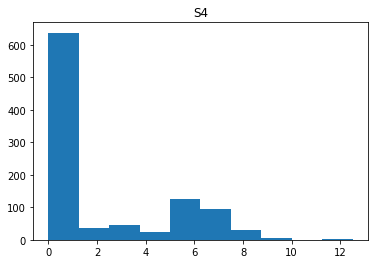

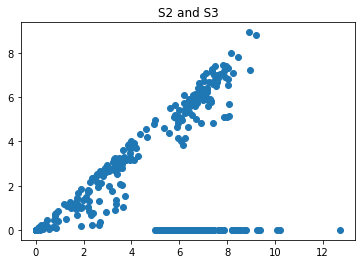

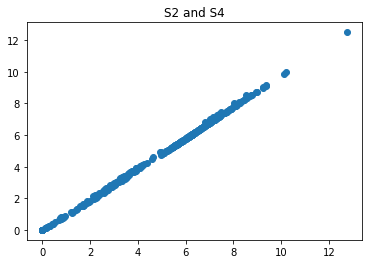

In [505]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

plt.hist(ssample["S1"])
plt.title("S1")
plt.show()

plt.hist(ssample["S2"])
plt.title("S2")
plt.show()

plt.scatter(ssample["S1"], ssample["S2"])
plt.title("S1 and S2")
plt.show()

plt.hist(ssample["S3"])
plt.title("S3")
plt.show()
plt.hist(ssample["S4"])
plt.title("S4")
plt.show()

# Summaries S3 and S4 (next and previous BSI from BSI_max) have an almost identical distribution to that of BSI_max 

plt.scatter(ssample["S2"], ssample["S3"])
plt.title("S2 and S3")
plt.show()
plt.scatter(ssample["S2"], ssample["S4"]) # Especially this. BSI_max_next
plt.title("S2 and S4")
plt.show()


## Rejection Sampling

In [506]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(1000, quantile=0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 19.5 s, sys: 232 ms, total: 19.7 s
Wall time: 19.5 s


In [507]:
# Prior and posterior in the same figure
par1 = "net_transmission"
par2 = "R"

if not reparam:
    sample = m.generate(1000, [par1, par2, 'OR_hat'])

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # OR_hat
    
    plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
    plt.title("OR_hat posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.show()
    
    # Joint prior: beta, OR
    
    plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and OR_hat")
    plt.xlabel(f"{par1}")
    plt.ylabel("OR")
    plt.legend(loc = "upper right")
    plt.show()
    
    
    # Joint prior: gamma, OR
    
    plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par2} and OR_hat")
    plt.xlabel(f"{par2}")
    plt.ylabel("OR")
    plt.legend(loc = "upper right")
    plt.show()


array([[<AxesSubplot: ylabel='OR_hat'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: ylabel='R'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: xlabel='OR_hat', ylabel='net_transmission'>,
        <AxesSubplot: xlabel='R'>,
        <AxesSubplot: xlabel='net_transmission'>]], dtype=object)

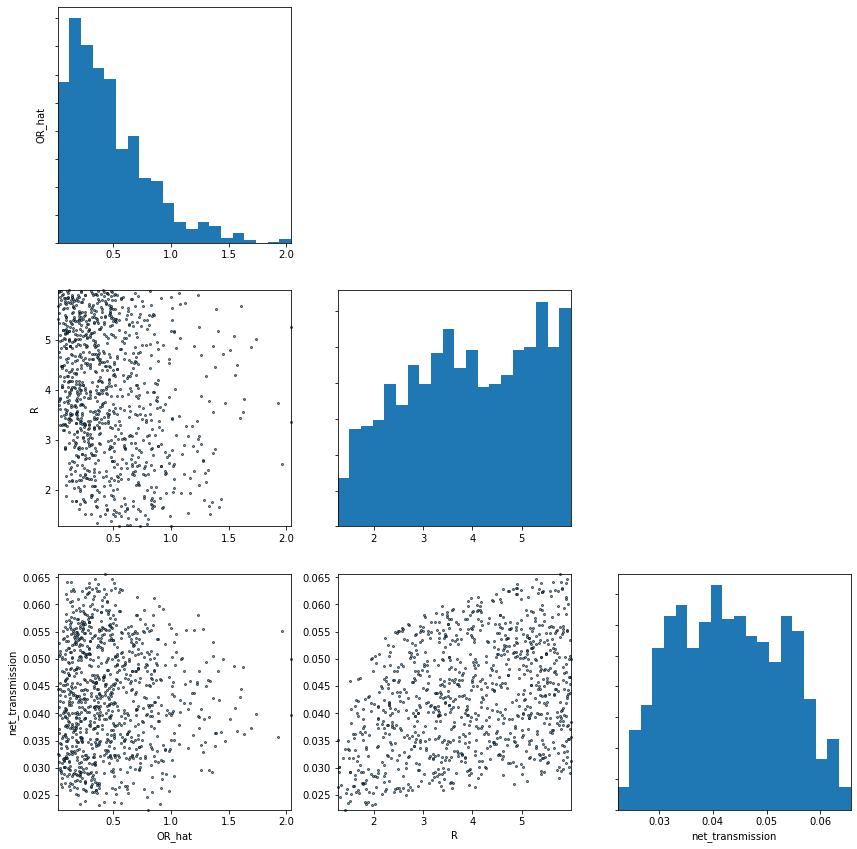

In [508]:
result.plot_pairs()

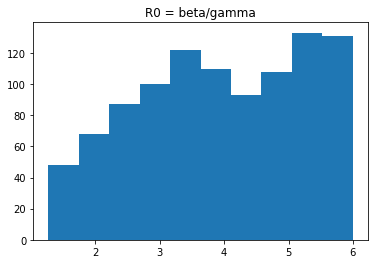

Mean of R: 3.942253553630745


In [509]:
# Plotting R0

if not reparam:
    R = result.samples['beta']/result.samples['gamma']
else:
    R = result.samples['R']

plt.hist(R)
plt.title("R0 = beta/gamma")
plt.show()

print(f"Mean of R: {R.mean()}")

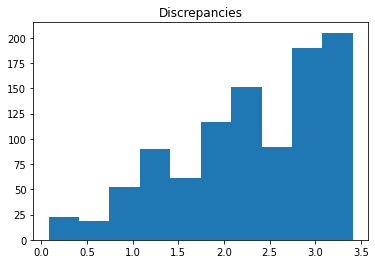

In [510]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.show()

In [511]:
# Is discrepancy ordered? -> is this plot valid?

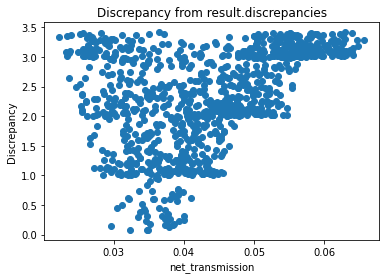

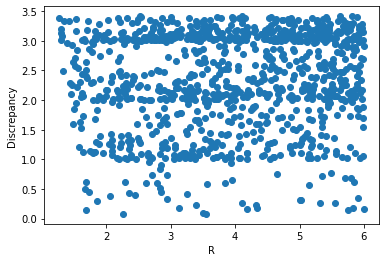

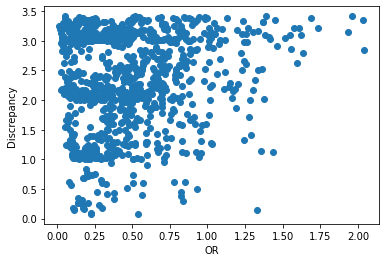

In [512]:
plt.scatter(result.samples[par1], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples['OR_hat'], result.discrepancies)
plt.xlabel("OR")
plt.ylabel("Discrepancy")
plt.show()

## Posterior predictive check

False
False
False


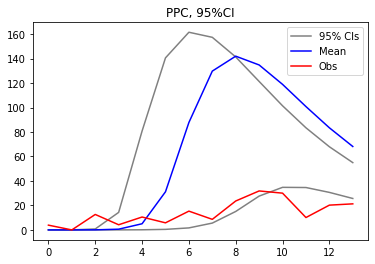

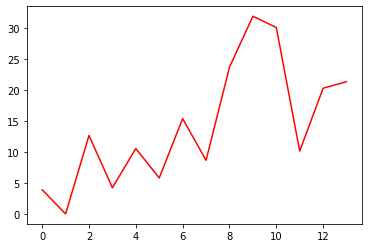

In [513]:
def get_ppc(ci = 95, par1 = "beta", par2 = "gamma"):
    # Get posterior predictive check: plot a simulated mean and credible intervals on top of the observed data.
    
    par1_ci = np.percentile(result.samples[par1], [(100-ci)/2, 100 - (100-ci)/2])
    par2_ci = np.percentile(result.samples[par2], [(100-ci)/2, 100 - (100-ci)/2])
    or_hat_ci = np.percentile(result.samples['OR_hat'], [(100-ci)/2, 100 - (100-ci)/2])
    
    par1_mean = result.samples[par1].mean()
    par2_mean = result.samples[par2].mean()
    or_mean = result.samples['OR_hat'].mean()
    
    lower_curve = SIR_and_BSI_simulator(par1 = par1_ci[0],\
                                            par2 = par2_ci[0],\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    
    upper_curve = SIR_and_BSI_simulator(par1 = par1_ci[1],\
                                            par2 = par2_ci[1],\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    
    mean_curve = SIR_and_BSI_simulator(par1 = par1_mean,\
                                            par2 = par2_mean,\
                                            nt = n_weeks, N = pop_size,\
                                            bsi_pars = bsi_pars,\
                                            is_prop = is_prop,\
                                            is_agg = is_agg,\
                                            time_period = time_period.generate(1),\
                                            reparam = reparam,\
                                            batch_size = 1,\
                                            random_state = None,\
                                            has_or_hat = True,
                                            manual_or_hat = or_mean)[0]
    

  
    plt.plot(upper_curve, label = f"{ci}% CIs", color = "grey")
    plt.plot(lower_curve, color = "grey")
    plt.plot(mean_curve, color = "blue", label = "Mean")
    plt.plot(np.array(bsi_obs_data), color = "red", label = "Obs")
    plt.title(f"PPC, {ci}%CI")
    plt.legend()
    plt.show()
    
    plt.plot(np.array(bsi_obs_data), color = "red")
    plt.show()
    
    # The randomness of OR impacts the heigth of the curves considerably. OR should be learned and the mean value used to visualize.
    # If I put the mean of OR for all credible intervals as parameter, I get a better curve.
    # But if I use the quantiles, it messes up the credible intervals in the figure. Why?
    
    
get_ppc(par1 = "net_transmission", par2 = "R")



In [514]:
# Pointwise PPC? Why does that above not work?